<a href="https://colab.research.google.com/github/estemartinez87-cell/Data-Science-III-NLP-Deep-Learning-/blob/main/Preentrega_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train: (8000, 2) | Test: (2000, 2)
Clases: ['Business', 'Sci_Tech', 'Sports', 'World']

Preprocesando train...
  72.4s
Preprocesando test...
  12.9s

=== Experimentación de vectorización (con LogisticRegression fijo) ===
  unigrama, sin límite de vocab       | vocab= 17513 | acc=0.8970 | F1-macro=0.8969
  unigrama, max_features=5000         | vocab=  5000 | acc=0.8950 | F1-macro=0.8950
  uni+bigrama, sin límite de vocab    | vocab=155044 | acc=0.8965 | F1-macro=0.8963
  uni+bigrama, max_features=5000      | vocab=  5000 | acc=0.8945 | F1-macro=0.8945

Mejor configuración de vectorización: unigrama, sin límite de vocab (F1-macro=0.8969)

=== Comparación de modelos baseline ===
  Naive Bayes            | acc=0.8970 | F1-macro=0.8973
  Logistic Regression    | acc=0.8970 | F1-macro=0.8969
  Linear SVM             | acc=0.8920 | F1-macro=0.8919

Modelo elegido como baseline final: Naive Bayes

=== Classification Report — Baseline (Naive Bayes) ===
              precision    recall  f1-scor

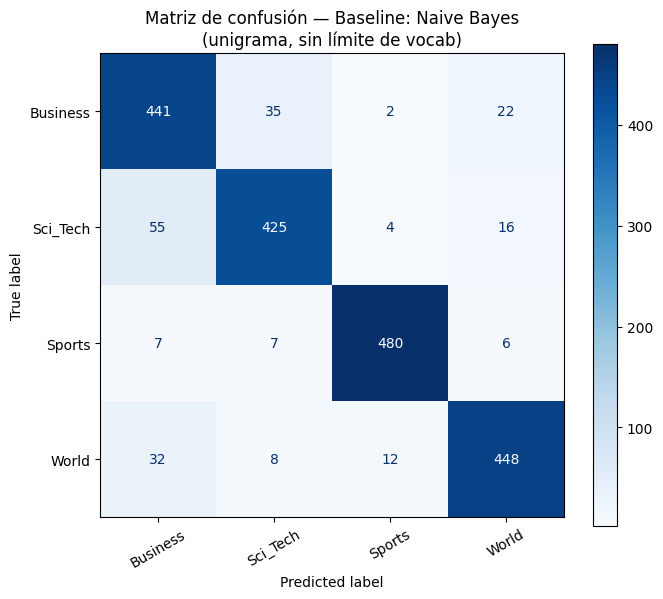


PARTE B — Fine-tuning con LoRA
GPU disponible: True
Dispositivo: Tesla T4


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.350351,0.355906,0.885000,0.885375,0.885000,0.885131
2,0.367907,0.322350,0.887500,0.887451,0.887500,0.887467
3,0.333601,0.315742,0.893000,0.893661,0.893000,0.893177



Tiempo de entrenamiento: 3.91 minutos


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.333601,0.315742,3,0.893000,0.893661,0.893000,0.893177



=== Métricas finales (Transformer + LoRA) ===
  eval_loss: 0.3157421946525574
  eval_accuracy: 0.893
  eval_precision_macro: 0.8936611244862939
  eval_recall_macro: 0.893
  eval_f1_macro: 0.8931773804994574

Última pérdida de entrenamiento (step logging): 0.3336008834838867
Pérdida promedio de todo el entrenamiento: 0.473075226465861
Pérdida final en validación: 0.3157421946525574



=== Classification Report — Transformer + LoRA ===
              precision    recall  f1-score   support

    Business     0.8258    0.8440    0.8348       500
    Sci_Tech     0.8619    0.8740    0.8679       500
      Sports     0.9643    0.9720    0.9681       500
       World     0.9226    0.8820    0.9018       500

    accuracy                         0.8930      2000
   macro avg     0.8937    0.8930    0.8932      2000
weighted avg     0.8937    0.8930    0.8932      2000



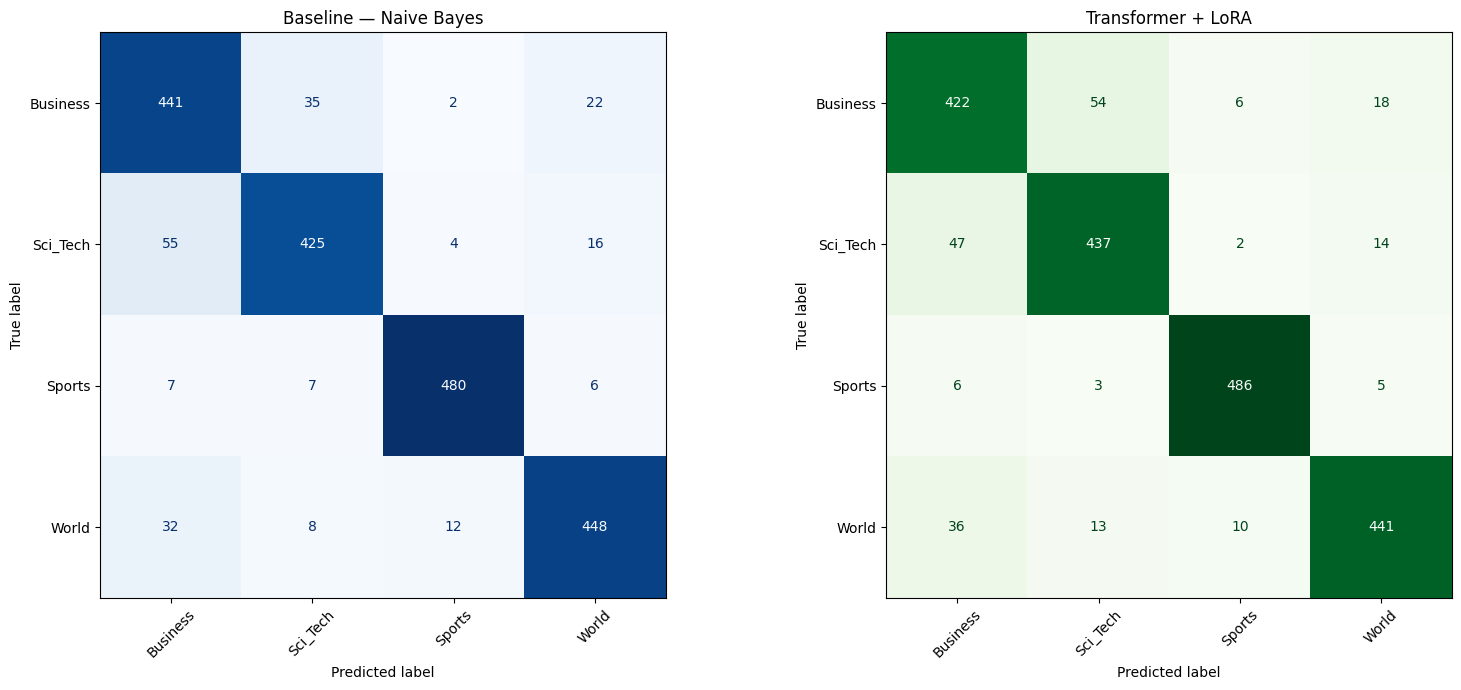


=== Tabla comparativa: Baseline vs Transformer+LoRA ===
          Métrica  Baseline: Naive Bayes  Transformer + LoRA  Delta (LoRA - Baseline)
         Accuracy               0.897000            0.893000                -0.004000
Precision (macro)               0.898365            0.893661                -0.004704
   Recall (macro)               0.897000            0.893000                -0.004000
       F1 (macro)               0.897280            0.893177                -0.004102


<Figure size 1000x600 with 0 Axes>

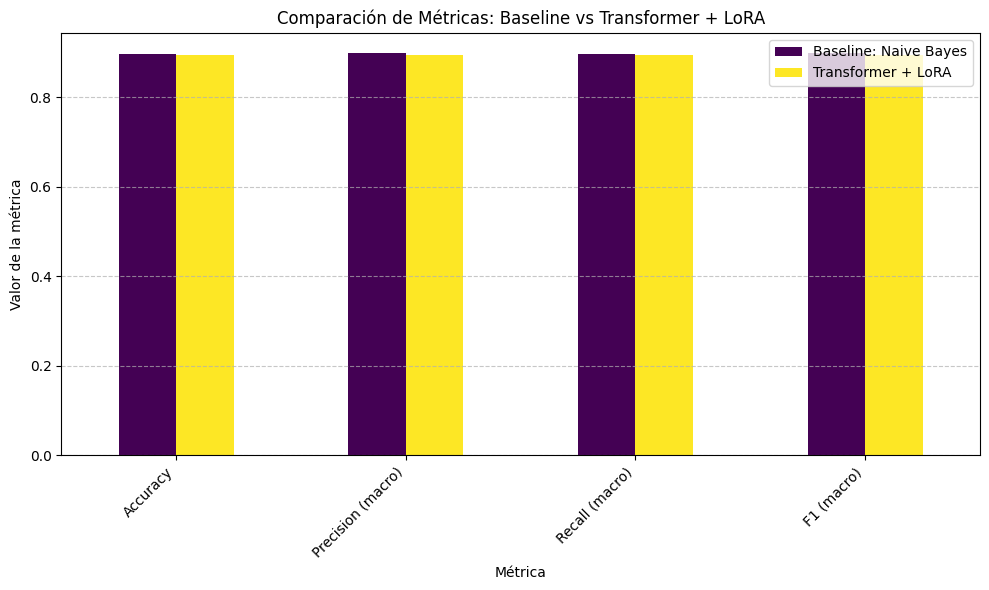


Listo. Reportes, matrices de confusión, benchmark y resumen guardados.
Guardá TODA la salida de consola (o hacé capturas) para armar el reporte en PDF.


In [6]:
# -*- coding: utf-8 -*-
"""
Checkpoint NLP III — Clasificación con fine-tuning eficiente mediante LoRA
Autora: Angelina Rosales
Dataset: AG News (mismo corpus de los Módulos 2 y 3).

INSTRUCCIONES DE USO:
1. Subí este script a Google Colab (o pegalo en una celda).
2. Subí tus archivos ag_news_train.csv y ag_news_test.csv a la sesión de
   Colab (icono de carpeta a la izquierda > Subir), o montá tu Google Drive.
   Ajustá TRAIN_PATH y TEST_PATH más abajo según corresponda.
3. Activá GPU: Entorno de ejecución > Cambiar tipo de entorno > GPU.
4. En una celda separada, ANTES de correr este script, ejecutá una vez:
     !pip install -q -U peft accelerate datasets transformers
     !python -m spacy download en_core_web_sm
5. Reiniciá el entorno (Entorno de ejecución > Reiniciar sesión) una vez
   instalado todo, y recién ahí corré este script completo de punta a punta.

Este script imprime TODOS los resultados que necesitás para el reporte:
tabla de vectorización, comparación de modelos, reporte de clasificación,
parámetros entrenables vs. totales, pérdida por época, y benchmark final.
Guardá la salida completa de la consola (o hacé capturas) para armar el PDF.
"""

# ===========================================================================
# IMPORTS
# ===========================================================================
import re
import html
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, TaskType

RANDOM_STATE = 42

# Ajustá estas rutas según dónde subiste los CSV en tu sesión de Colab
TRAIN_PATH = "/ag_news_train.csv"
TEST_PATH = "/ag_news_test.csv"

# ===========================================================================
# PARTE A — BASELINE (Módulo 3): TF-IDF + clasificadores clásicos
# ===========================================================================
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print("Clases:", sorted(train_df["label"].unique()))

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
STOPWORDS = nlp.Defaults.stop_words


def clean_text(text: str) -> str:
    text = html.unescape(text)
    text = re.sub(r"#39;", "'", text)
    text = re.sub(r"&lt;.*?&gt;", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = text.replace("\\", "")
    text = re.sub(r"[^A-Za-z0-9\s'-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def batch_preprocess(texts, remove_stopwords=True):
    cleaned = [clean_text(t).lower() for t in texts]
    out = []
    for doc in nlp.pipe(cleaned, batch_size=200):
        tokens = [
            tok.lemma_
            for tok in doc
            if not tok.is_punct and not tok.is_space and tok.lemma_.strip() != ""
        ]
        if remove_stopwords:
            tokens = [t for t in tokens if t not in STOPWORDS]
        out.append(" ".join(tokens))
    return out


print("\nPreprocesando train...")
t0 = time.time()
train_df["clean_text"] = batch_preprocess(train_df["text"].tolist())
print(f"  {time.time() - t0:.1f}s")
print("Preprocesando test...")
t0 = time.time()
test_df["clean_text"] = batch_preprocess(test_df["text"].tolist())
print(f"  {time.time() - t0:.1f}s")

X_train_text, y_train = train_df["clean_text"], train_df["label"]
X_test_text, y_test = test_df["clean_text"], test_df["label"]

configs = [
    {"name": "unigrama, sin límite de vocab", "max_features": None, "ngram_range": (1, 1)},
    {"name": "unigrama, max_features=5000", "max_features": 5000, "ngram_range": (1, 1)},
    {"name": "uni+bigrama, sin límite de vocab", "max_features": None, "ngram_range": (1, 2)},
    {"name": "uni+bigrama, max_features=5000", "max_features": 5000, "ngram_range": (1, 2)},
]

print("\n=== Experimentación de vectorización (con LogisticRegression fijo) ===")
vec_results = []
for cfg in configs:
    vectorizer = TfidfVectorizer(max_features=cfg["max_features"], ngram_range=cfg["ngram_range"])
    Xtr = vectorizer.fit_transform(X_train_text)
    Xte = vectorizer.transform(X_test_text)
    clf = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    preds = clf.predict(Xte)
    f1_macro = f1_score(y_test, preds, average="macro")
    acc = accuracy_score(y_test, preds)
    print(f"  {cfg['name']:<35} | vocab={Xtr.shape[1]:>6} | acc={acc:.4f} | F1-macro={f1_macro:.4f}")
    vec_results.append({**cfg, "vocab_size": Xtr.shape[1], "accuracy": acc, "f1_macro": f1_macro})

best_cfg = max(vec_results, key=lambda r: r["f1_macro"])
print(f"\nMejor configuración de vectorización: {best_cfg['name']} (F1-macro={best_cfg['f1_macro']:.4f})")

vectorizer = TfidfVectorizer(max_features=best_cfg["max_features"], ngram_range=best_cfg["ngram_range"])
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
}
print("\n=== Comparación de modelos baseline ===")
model_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro")
    model_results[name] = {"model": model, "preds": preds, "accuracy": acc, "f1_macro": f1_macro}
    print(f"  {name:<22} | acc={acc:.4f} | F1-macro={f1_macro:.4f}")

best_model_name = max(model_results, key=lambda k: model_results[k]["f1_macro"])
best_model = model_results[best_model_name]["model"]
best_preds = model_results[best_model_name]["preds"]
print(f"\nModelo elegido como baseline final: {best_model_name}")

baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    y_test, best_preds, average="macro", zero_division=0
)

labels = sorted(y_train.unique())
report = classification_report(y_test, best_preds, digits=4)
print(f"\n=== Classification Report — Baseline ({best_model_name}) ===")
print(report)

with open("classification_report_baseline.txt", "w") as f:
    f.write(f"Modelo: {best_model_name}\n")
    f.write(f"Vectorizador: {best_cfg['name']} (max_features={best_cfg['max_features']}, ngram_range={best_cfg['ngram_range']})\n\n")
    f.write(report)

cm_baseline = confusion_matrix(y_test, best_preds, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=30)
plt.title(f"Matriz de confusión — Baseline: {best_model_name}\n({best_cfg['name']})")
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150)
plt.show()

# ===========================================================================
# PARTE B — FINE-TUNING EFICIENTE CON LoRA (PEFT)
# ===========================================================================
print("\n" + "=" * 70)
print("PARTE B — Fine-tuning con LoRA")
print("=" * 70)
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Dispositivo:", torch.cuda.get_device_name(0))
else:
    print("ADVERTENCIA: no hay GPU activa. Andá a Entorno de ejecución > "
          "Cambiar tipo de entorno > GPU antes de seguir, o el entrenamiento "
          "va a ser muchísimo más lento.")

label2id = {name: i for i, name in enumerate(sorted(train_df["label"].unique()))}
id2label = {i: name for name, i in label2id.items()}
train_dataset = Dataset.from_dict({
    "text": train_df["text"].tolist(),
    "label": train_df["label"].map(label2id).tolist(),
})
test_dataset = Dataset.from_dict({
    "text": test_df["text"].tolist(),
    "label": test_df["label"].map(label2id).tolist(),
})

# ---------------------------------------------------------------------------
# Punto 1 — Selección y justificación del modelo base
# ---------------------------------------------------------------------------
# DistilBERT (distilbert-base-uncased): corpus en inglés (no hace falta
# modelo multilingüe) y ~40% menos parámetros que BERT-base (66M vs 110M)
# reteniendo ~97% de su rendimiento — ideal para GPU gratuita de Colab.
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)


def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)


train_tok = train_dataset.map(tokenize_function, batched=True)
test_tok = test_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=len(label2id), id2label=id2label, label2id=label2id
)

# ---------------------------------------------------------------------------
# Punto 2 — Configuración de LoRA (r, alpha, target_modules)
# ---------------------------------------------------------------------------
# r=8: clasificación de 4 clases es una tarea de complejidad baja/media,
#   un rango bajo alcanza para capturar la señal sin parámetros de más.
# lora_alpha=16 (=2*r): convención estándar de escalado.
# target_modules=["q_lin","v_lin"]: proyecciones query/value de la atención
#   en DistilBERT, mejor relación costo/beneficio según el paper de LoRA.
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    bias="none",
)
model = get_peft_model(model, lora_config)

# ---------------------------------------------------------------------------
# Punto 4 — Análisis de parámetros: totales vs. entrenables
# ---------------------------------------------------------------------------
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
pct_trainable = 100 * trainable_params / total_params
print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,} ({pct_trainable:.4f}%)")
model.print_trainable_parameters()

# ---------------------------------------------------------------------------
# Punto 3 — Entrenamiento: fine-tuning + pérdida final train vs. validación
# ---------------------------------------------------------------------------
training_args = TrainingArguments(
    output_dir="./lora-agnews",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_steps=50,
)


def compute_metrics(eval_pred):
    logits, labels_ = eval_pred
    preds = logits.argmax(axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_, preds, average="macro", zero_division=0
    )
    return {
        "accuracy": (preds == labels_).mean(),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer.train()
training_time = time.time() - t0
print(f"\nTiempo de entrenamiento: {training_time / 60:.2f} minutos")

lora_metrics = trainer.evaluate()
print("\n=== Métricas finales (Transformer + LoRA) ===")
for k, v in lora_metrics.items():
    print(f"  {k}: {v}")

train_loss_steps = [entry["loss"] for entry in trainer.state.log_history if "loss" in entry]
final_train_loss = train_loss_steps[-1] if train_loss_steps else None
train_summary = [entry for entry in trainer.state.log_history if "train_loss" in entry]
avg_train_loss = train_summary[-1]["train_loss"] if train_summary else None
print(f"\nÚltima pérdida de entrenamiento (step logging): {final_train_loss}")
print(f"Pérdida promedio de todo el entrenamiento: {avg_train_loss}")
print(f"Pérdida final en validación: {lora_metrics['eval_loss']}")

lora_predictions_output = trainer.predict(test_tok)
lora_preds_ids = lora_predictions_output.predictions.argmax(axis=-1)
lora_preds_labels = [id2label[pred_id] for pred_id in lora_preds_ids]
lora_report = classification_report(y_test, lora_preds_labels, digits=4)
print("\n=== Classification Report — Transformer + LoRA ===")
print(lora_report)

with open("classification_report_lora.txt", "w") as f:
    f.write(f"Modelo: {model_ckpt} + LoRA (r={lora_config.r}, alpha={lora_config.lora_alpha})\n\n")
    f.write(lora_report)

cm_lora = confusion_matrix(y_test, lora_preds_labels, labels=labels)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=labels).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title(f"Baseline — {best_model_name}")
ConfusionMatrixDisplay(confusion_matrix=cm_lora, display_labels=labels).plot(
    ax=axes[1], cmap="Greens", colorbar=False, xticks_rotation=45
)
axes[1].set_title("Transformer + LoRA")
plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png", dpi=150)
plt.show()

# ---------------------------------------------------------------------------
# Punto 5 — Benchmark final: tabla comparativa Baseline vs. Transformer+LoRA
# ---------------------------------------------------------------------------
comparison = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"],
    f"Baseline: {best_model_name}": [
        model_results[best_model_name]["accuracy"], baseline_precision, baseline_recall, baseline_f1
    ],
    "Transformer + LoRA": [
        lora_metrics["eval_accuracy"], lora_metrics["eval_precision_macro"],
        lora_metrics["eval_recall_macro"], lora_metrics["eval_f1_macro"],
    ],
})
comparison["Delta (LoRA - Baseline)"] = (
    comparison["Transformer + LoRA"] - comparison[f"Baseline: {best_model_name}"]
)
print("\n=== Tabla comparativa: Baseline vs Transformer+LoRA ===")
print(comparison.to_string(index=False))
comparison.to_csv("benchmark_comparison.csv", index=False)

fig = plt.figure(figsize=(10, 6))
comparison.set_index("Métrica")[[f"Baseline: {best_model_name}", "Transformer + LoRA"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis"
)
plt.title("Comparación de Métricas: Baseline vs Transformer + LoRA")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("benchmark_comparison.png", dpi=150)
plt.show()

# ---------------------------------------------------------------------------
# Guardar resumen estructurado (para armar el reporte)
# ---------------------------------------------------------------------------
summary = {
    "baseline": {
        "best_vec_config": {k: v for k, v in best_cfg.items()},
        "vec_experiments": vec_results,
        "model_comparison": {
            k: {"accuracy": v["accuracy"], "f1_macro": v["f1_macro"]} for k, v in model_results.items()
        },
        "best_model": best_model_name,
    },
    "lora": {
        "model_ckpt": model_ckpt,
        "lora_r": lora_config.r,
        "lora_alpha": lora_config.lora_alpha,
        "target_modules": list(lora_config.target_modules),
        "total_params": total_params,
        "trainable_params": trainable_params,
        "pct_trainable": pct_trainable,
        "training_time_minutes": training_time / 60,
        "final_train_loss_step": final_train_loss,
        "avg_train_loss": avg_train_loss,
        "eval_loss": lora_metrics["eval_loss"],
        "eval_accuracy": lora_metrics["eval_accuracy"],
        "eval_precision_macro": lora_metrics["eval_precision_macro"],
        "eval_recall_macro": lora_metrics["eval_recall_macro"],
        "eval_f1_macro": lora_metrics["eval_f1_macro"],
    },
    "n_train": len(train_df),
    "n_test": len(test_df),
}
with open("summary_lora.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nListo. Reportes, matrices de confusión, benchmark y resumen guardados.")
print("Guardá TODA la salida de consola (o hacé capturas) para armar el reporte en PDF.")

In [2]:
import torch

print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Dispositivo GPU:", torch.cuda.get_device_name(0))
else:
    print("ADVERTENCIA: No hay GPU activa. Para activarla, ve a 'Entorno de ejecución' > 'Cambiar tipo de entorno de ejecución' y selecciona 'GPU'. Después de cambiar, reinicia el entorno y ejecuta todas las celdas.")

GPU disponible: True
Dispositivo GPU: Tesla T4


In [3]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 68.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


# Sección nueva